# 📂 A-. Fundamentos del Sistema de Riesgo

- 🎯 Construction of default prediction base model

## 📌 1-. Formal Definition of the Problem

Given a set of financial and demographic variables of a client:

$
X = (x_1, x_2, x_3,...,x_n)
$

predict

$
P(Default = 1|X)
$

It is a supervised binary classification problem.

### 1.1-. Supervised Binary Classification

**Supervised binary classification** is a machine learning problem where the goal is to assign each observation to one of two mutually exclusive classes, using a pre-labeled dataset.

Formally:

$ y \in \{0,1\} $

Given a dataset:

$ D = \{(x_i, y_i)\}_{i=1}^{n} $

where:

- $ x_i \in \mathbb{R}^p $ → feature vector
- $ y_i \in \{0,1\} $ → binary label

The goal is to learn a function:

$ f(x) \rightarrow P(y=1|x) $

---

#### Use Cases

| Domain | Class 0 | Class 1 |
----------|----------|----------|
| Credit Risk | No Default | Default |
| Medicine | No Illness | Illness |
| Marketing | No Purchase | Purchase |
| Spam Detection | No Spam | Spam |
| Fraud Detection | Legitimate Transaction | Fraud |

---

#### Common Models

##### 1. Logistic Regression

Probabilistic linear model:

$ P(y=1|x) = \sigma(w^Tx + b) $

Advantages:

- Interpretability (odds ratio)
- Good baseline
- Good probabilistic calibration

---

##### 2. Decision Trees

- Nonlinear
- Automatically capture interactions
- Interpretable at shallow depths

---

##### 3. Random Forest

- Bagging-type ensemble
- Reduces variance
- Robust against overfitting

---

##### 4. Gradient Boosting

- XGBoost  
- LightGBM  
- CatBoost  

Advantages:

- High performance with tabular data
- Efficient handling of categorical variables (especially CatBoost)
- State-of-the-art for many industrial problems

---

##### 5. Neural Networks

- Useful for large datasets
- Model complex relationships
- Lower interpretability

---

#### Evaluation Metrics

Confusion matrix:

|              | Pred 0 | Pred 1 |
|--------------|--------|--------|
| Real 0       | TN     | FP     |
| Real 1       | FN     | TP     |

Key metrics:

- Accuracy
- Precision
- Recall (Sensitivity)
- Specificity
- F1-score
- ROC-AUC
- PR-AUC (especially useful in unbalanced datasets)

---

#### Problem: Class Imbalance

Example:

- 95% Class 0
- 5% Class 1

Accuracy can be misleading.

Common solutions:

- Adjust class weights
- Oversampling (SMOTE)
- Undersampling
- Threshold adjustment
- Optimize metrics such as Recall, F1, or PR-AUC


---

Typical Modeling Workflow

1. Data Exploration and Cleaning
2. Feature Engineering
3. Train/Validation/Test Split
4. Modeling
5. Cross-validation
6. Hyperparameter Tuning
7. Evaluation with Appropriate Metrics
8. Threshold Selection
9. Interpretability (SHAP, Feature Importance)
10. Production Monitoring

---

#### Model Output

In binary classification, not only the class matters, but also the estimated probability:

$
\hat{y} =
\begin{cases}
1 & \text{if } P(y=1|x) > \tau \\
0 & \text{if } P(y=1|x) \leq \tau
\end{cases}
$

Where:

- $\tau$ es el threshold (not necessary 0.5)
- Setting $\tau$ allows us improve metrics according to the goal of the bussines.

---

### Conceptual Summary

Supervised binary classification consists of:

- Learning a decision boundary
- Estimating conditional probabilities
- Optimizing a loss function (log-loss, hinge loss, etc.)
- Evaluating performance using metrics consistent with the business objective

It is one of the fundamental problems in applied machine learning.


## 🧾 2-. Exploratory Data Analysis


### 2.1-. Objetivo

The goal of this exploratory analysis is to understand the structure of the credit risk dataset, identify relevant patterns, and prepare data for predictive modeling.

### 2.2-. Dataset

[Default of Credit Card Clients (UCI)](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

This dataset contains customer financial and demographic information, along with a target variable that indicates whether the customer will default on payment next month.

### 2.3.- Objective Variable

* default.payment.next.month
* 1 = Default
* 0 = No Default

### 2.4-. EDA Objectives

* Understanding the distribution of the target
* Identify predictive variables
* Detect outliers
* Evaluate correlations
* Identify data quality issues


# 🔎 B-. EDA (Exploratory Analysis)

## 📊 1-. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# style="whitegrid" → sets a white background with grid lines.
sns.set(style="whitegrid")

# It tells Jupyter or Colab to display plots directly inside the notebook, instead of opening them in a separate window.
%matplotlib inline

## 📥 2-. Data Load

In [ ]:
df = pd.read_excel('default_of_credit_card_clients.xls', header = 1)
df.head(3)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 🔎 3-. General view

In [ ]:
df.shape

(30000, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 🧾 3.1-. Documentation

#### Overview of the Dataset

The dataset contains financial and demographic information from credit card customers.

They are analyzed:
- Number of observations
- Types of data
- Descriptive statistics

This analysis allows to identify possible problems of quality and initial distribution of variables.

### 3.2-. Null values

In [ ]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


### 3.3-. Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

### 🧾 3.4-. Documentation

#### Data Quality

They are evaluated:
- Null values
- Duplicate records

This allows to identify problems that could affect subsequent modeling.

### 🎯 3.5-. Target Analysis

In [ ]:
df['default_payment_next_month'].value_counts()

,count
default_payment_next_month,
0,23364
1,6636


In [ ]:
df['default_payment_next_month'].value_counts(normalize=True)

,proportion
default_payment_next_month,
0,0.7788
1,0.2212


### 📊 3.6-. Target visualization

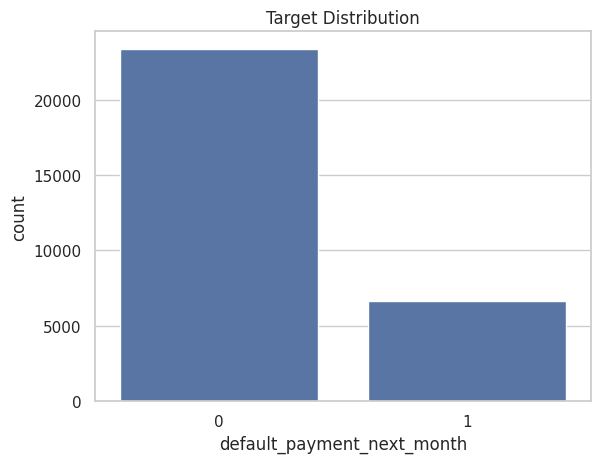

In [ ]:
sns.countplot(x='default_payment_next_month', data=df)
plt.title("Target Distribution")
plt.show()

### 🧾 3.7-. Documentation

#### Distribution of Target

The proportion of customers who default against those who do not breach is analyzed.

This analysis is important for detecting class imbalance, which can influence model performance.

As we can see, classes are highly imbalanced to 0.
- ~22% default
- ~78% no default

This is a moderate inbalance (realistic), because at real credit risk default is usually a rare but not extremely rare event.

In [ ]:
pd.crosstab(df['SEX'], df['default_payment_next_month'], normalize='index')

default_payment_next_month,0,1
SEX,,
1,0.758328,0.241672
2,0.792237,0.207763


# 📊 C-. Bivariate Analysis (Default vs Variables)

## 🎯 Objective

This section analyzes the relationship between predictor variables and the target variable (default).

The objective is to identify variables with predictive power for later modeling

## 📊 1-. Default vs LIMIT_BAL

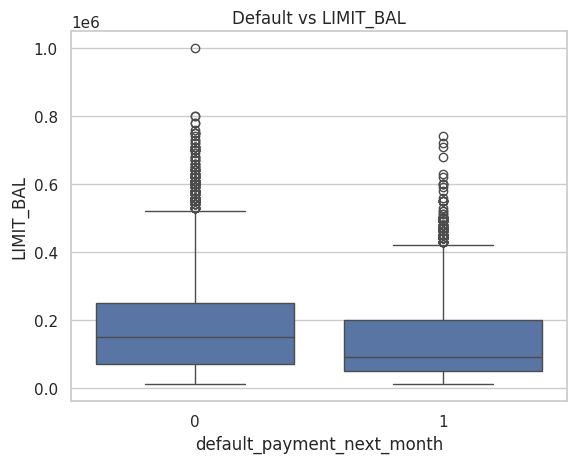

In [ ]:
sns.boxplot(x='default_payment_next_month', y='LIMIT_BAL', data=df)
plt.title("Default vs LIMIT_BAL")
plt.show()

### 🧾 1.1-. Documentation

- Customers with a lower credit limit represent a higher risk.
- Custumers with lower risk have a higher amount of credit and his median bigger than customers with higher risk.


## 📊 2-. Default vs AGE

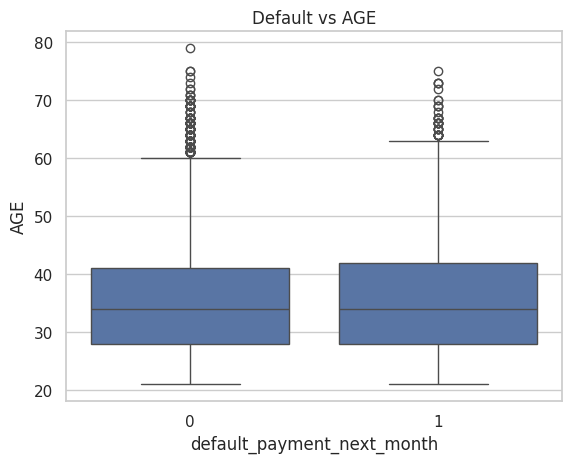

In [ ]:
sns.boxplot(x='default_payment_next_month', y='AGE', data=df)
plt.title("Default vs AGE")
plt.show()

### 🧾 2.1-. Documentation

As we can see, both young and older customers present the same behavioral risk.

## 📊 3—. Default vs payment history

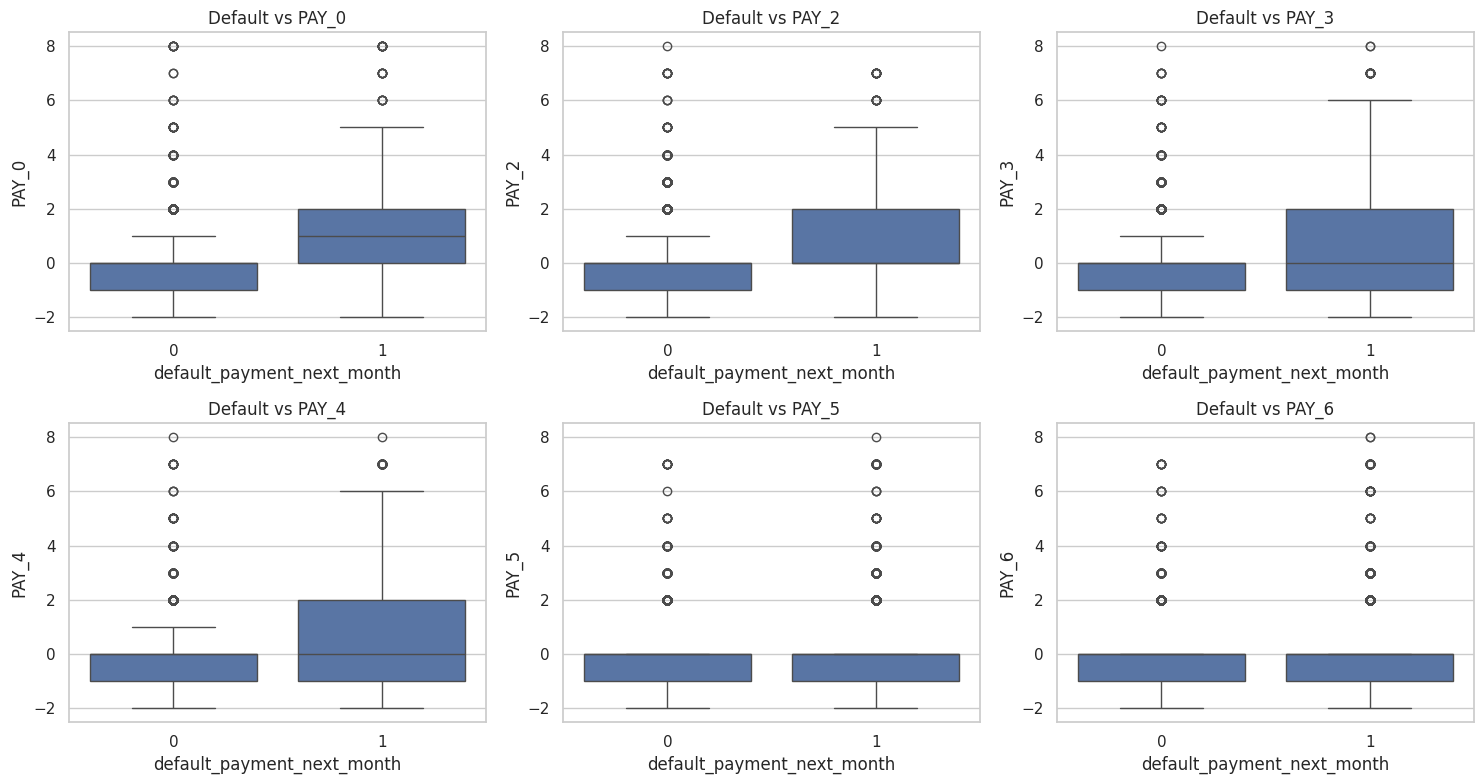

In [ ]:
pay_vars = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(pay_vars):
    sns.boxplot(
        x='default_payment_next_month',
        y=var,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"Default vs {var}")

plt.tight_layout()
plt.show()